# Introduction to torx

In [31]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from torx import (
    DiscretePCircuit,
    draw_circuit,
    PCNOT,
    PISING,
    PNOT,
    PSWAP,
    SampleSimulator,
    StateVectorSimulator,
)
from tqdm import tqdm

## State Vector Simulator

Set up and train a parameterized state vector simulation.

In [32]:
circuit = DiscretePCircuit(
    [
        PNOT(jnp.array(np.random.uniform(-1, 1)), 0),
        PSWAP(jnp.array(np.random.uniform(-1, 1)), [0, 1]),
        PCNOT(jnp.array(np.random.uniform(-1, 1)), [1, 0]),
    ]
)

sim = StateVectorSimulator()

optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(eqx.filter(circuit, eqx.is_inexact_array))
# init_state = jnp.ones(4) * 1/4
init_state = jnp.zeros(4, dtype=jnp.float32).at[0].set(1.0)
print(init_state)
draw_circuit(circuit)


@eqx.filter_value_and_grad
def loss_fn(circuit):
    state = sim.density(circuit, init_state)

    # simple L2 loss
    target = jnp.array([0.5, 0, 0, 0.5])
    return jnp.sum((target - state) ** 2)


@eqx.filter_jit
def do_step(circuit, opt_state):
    loss, grads = loss_fn(circuit)
    updates, opt_state = optimizer.update(eqx.filter(grads, eqx.is_array), opt_state)
    circuit = eqx.apply_updates(circuit, updates)
    return circuit, opt_state, loss

[1. 0. 0. 0.]
     ┌──────┐┌───────┐┌───────┐  
p_0: ┤ PNOT ├┤ PSWAP ├┤ PCNOT ├──
     └──────┘│       │└───┬───┘  
             │       │    │      
p_1: ────────┤       ├────■──────
             └───────┘           


In [23]:
train_loop = tqdm(range(1000))
losses = []

for step in train_loop:
    circuit, opt_state, loss = do_step(circuit, opt_state)
    losses.append(loss)

    train_loop.set_description(f"Step {step + 1}, Loss {loss:.5f}")

Step 1000, Loss 0.00212: 100%|██████████| 1000/1000 [00:02<00:00, 387.73it/s]


In [24]:
sim.density(circuit, init_state)

Array([0.47945827, 0.02856351, 0.01652976, 0.4754485 ], dtype=float32)

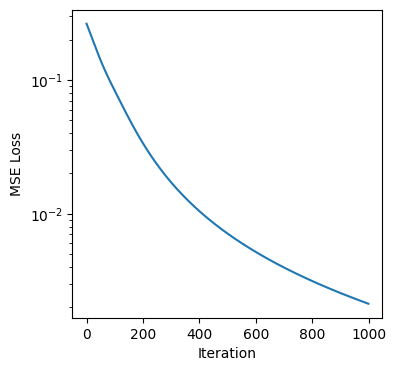

In [25]:
plt.figure(figsize=(4, 4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.show()

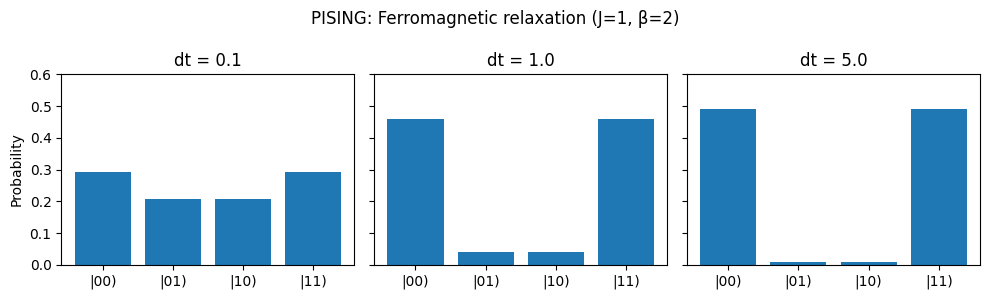

In [26]:
sim = StateVectorSimulator()
init_state = jnp.ones(4) / 4  # uniform over |00), |01), |10), |11)

# Ferromagnetic coupling (J=1) at inverse temperature beta=2
# Sweep dt to show relaxation toward equilibrium
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, dt in zip(axes, [0.1, 1.0, 5.0]):
    gate = PISING(jnp.array([1.0, 0.0, 0.0, 2.0, dt]), [0, 1])
    dist = sim.density(DiscretePCircuit([gate]), init_state)
    ax.bar(["|00)", "|01)", "|10)", "|11)"], dist)
    ax.set_title(f"dt = {dt}")
    ax.set_ylim(0, 0.6)
axes[0].set_ylabel("Probability")
fig.suptitle("PISING: Ferromagnetic relaxation (J=1, β=2)")
plt.tight_layout()
plt.show()

## PISING: Energy-Based Gate

Unlike Boolean gates (PNOT, PCNOT, …), PISING thermalizes two pbits toward the Boltzmann distribution of a 2-spin Ising model via Glauber dynamics. Parameters: `[J, h1, h2, beta, dt]`.

## Circuit Gradients

Compute parameter shift gradients and compare their sampled estimates to the exact state vector gradients.

In [27]:
theta1 = np.random.uniform(-1, 1)
theta2 = np.random.uniform(-1, 1)
theta3 = np.random.uniform(-1, 1)

circuit = DiscretePCircuit(
    [
        PNOT(jnp.array(theta1), 0),
        PSWAP(jnp.array(theta2), [0, 1]),
        PCNOT(jnp.array(theta3), [1, 0]),
    ]
)

circuit_vec = DiscretePCircuit(
    [
        PNOT(jnp.array(theta1), 0),
        PSWAP(jnp.array(theta2), [0, 1]),
        PCNOT(jnp.array(theta3), [1, 0]),
    ]
)

sim = SampleSimulator(num_samples=1000, diff_method="param_shift_inf")
statevec_sim = StateVectorSimulator()

circuit = sim.build_circuit(circuit)

key = jax.random.key(0)
optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(eqx.filter(circuit, eqx.is_inexact_array))

optimizer_vec = optax.adam(learning_rate=1e-2)
opt_statevec = optimizer_vec.init(eqx.filter(circuit_vec, eqx.is_inexact_array))
init_statevec = jnp.zeros(4, dtype=jnp.float32).at[0].set(1.0)
# init_state = jax.nn.softmax(jnp.array(np.random.uniform(0, 1, size=4)))
# init_state = jnp.zeros(2, dtype=jnp.int32).at[0].set(1)
init_state = jnp.array([0, 0])


@eqx.filter_value_and_grad
def loss_fn_exp(circuit, key):
    exp = sim.expval(circuit, init_state, 1, key)
    return -exp


@eqx.filter_value_and_grad
def loss_fn_vec(circuit):
    exp = statevec_sim.expval(circuit, init_statevec, 1)
    return -exp


@eqx.filter_jit
def do_step(circuit, opt_state, key):
    loss, grads = loss_fn_exp(circuit, key)
    updates, opt_state = optimizer.update(
        grads, opt_state, eqx.filter(circuit, eqx.is_array)
    )
    circuit = eqx.apply_updates(circuit, updates)
    return circuit, opt_state, loss


@eqx.filter_jit
def do_step_vec(circuit, opt_state):
    loss, grads = loss_fn_vec(circuit)
    updates, opt_state = optimizer_vec.update(
        eqx.filter(grads, eqx.is_inexact_array), opt_state
    )
    circuit = eqx.apply_updates(circuit, updates)
    return circuit, opt_state, loss

In [28]:
miniters = 100
train_loop = tqdm(range(2000), miniters=miniters)
losses = []
losses_vec = []
key = jax.random.key(0)

for step in train_loop:
    key, subkey = jax.random.split(key)
    circuit, opt_state, loss = do_step(circuit, opt_state, subkey)
    losses.append(loss)

    if step % miniters == 0:
        train_loop.set_description(f"Step {step + 1}, Loss {loss:.5f}")

train_loop = tqdm(range(2000), miniters=miniters)
for step in train_loop:
    circuit_vec, opt_statevec, loss_vec = do_step_vec(circuit_vec, opt_statevec)
    losses_vec.append(loss_vec)

    if step % miniters == 0:
        train_loop.set_description(f"Step {step + 1}, Statevector Loss {loss_vec:.5f}")

Step 1901, Statevector Loss -0.99378: 100%|██████████| 2000/2000 [00:02<00:00, 787.51it/s] 


In [29]:
print(init_state)
print(sim.expval(circuit, init_state, 1, key))
print(init_statevec)
print(statevec_sim.expval(circuit_vec, init_statevec, 1))

[0 0]
0.994
[1. 0. 0. 0.]
0.9943588


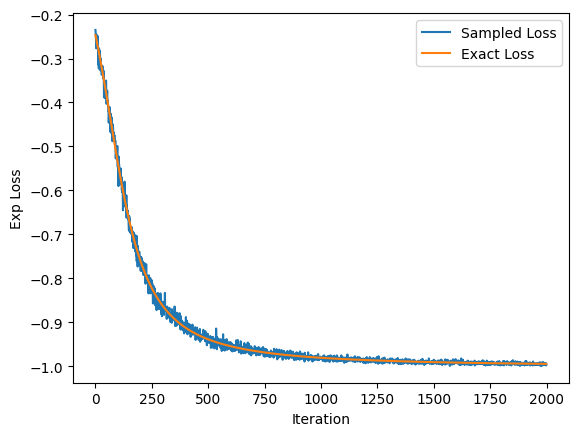

In [30]:
plt.plot(losses, label="Sampled Loss")
plt.plot(losses_vec, label="Exact Loss")
plt.xlabel("Iteration")
plt.ylabel("Exp Loss")
plt.legend(loc="best")
# plt.yscale("log")
plt.show()